<a href="https://colab.research.google.com/github/tarynglover/tarynglover_INFO4670_Spring2026/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [27]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

In the situation of spam messages, I believe false negatives are the more costly error. This would mean that a spam message is not flagged as spam and makes it to the user. For example, a phishing scam message might make it to a user, and prompt them to click a link that allows a virus through or their information to be stolen. A false postive would still be an inconvinient error, however not as costly in my opinion. This means a real message that is intended for the user is flagged as spam and may not be delivered or is sent to a spam folder. This might be annoying, but no harm is done to the user like in the situation of a false negative.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

I believe recall is the most valuable metric in spam detection. Because recall directly means the amount of true positives out of all the true positives and false negatives, or in other words, how much spam is detected out of all the spam that existed. In a dataset that is imbalanced, this metric would be most useful since it is only looking at instances of spam. A model with high recall means that it is capturing most spam and minimizing the amount of false negatives.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

If a dataset is 13% spam, and a dummy model is always predicting the messages are "ham", then the accuracy would be about 87%. That number would be very misleading because the model is predicting 0% of the spam messages. This is the danger of using an imbalanced dataset. Relying on the relatively high accuracy is hiding that the model is catching 0% of the spam.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [28]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


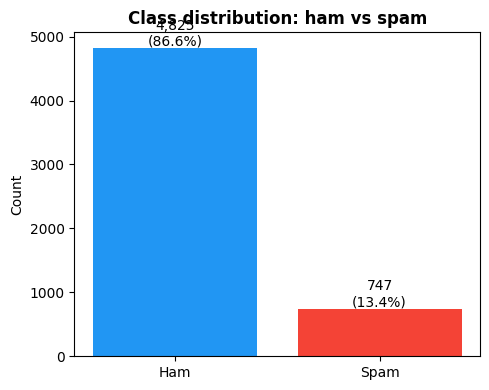

In [29]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [30]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


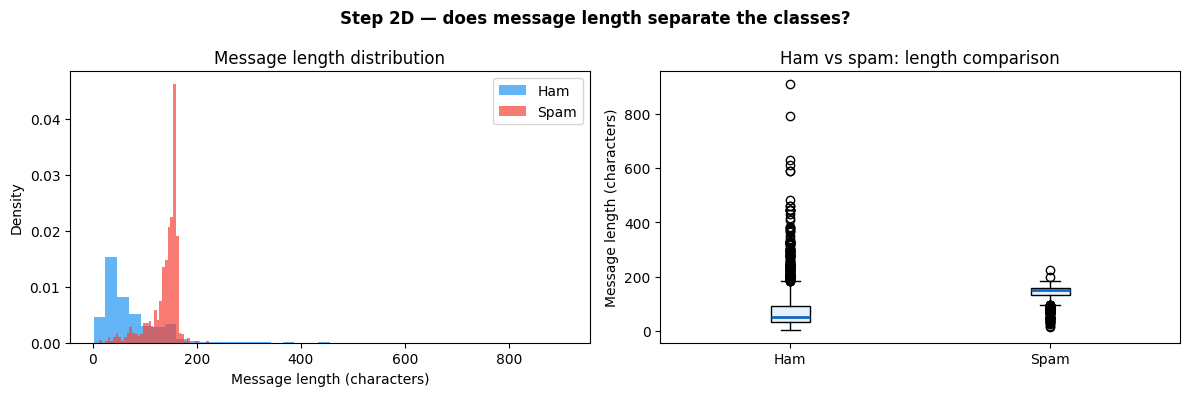

In [31]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [32]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [33]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: message has call to action words ---
    d['text_command'] = msg.str.contains(
        r'txt|text|reply|won',
        regex=True
    ).astype(int)

    # --- Feature 6: message contains sus words  ---
    d['spam_keywords'] = msg.str.contains(
        r'guaranteed|prize|selected|congratulations',
        regex=True
    ).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
text_command           55.3%    4.8%  +50.5%
spam_keywords          17.0%    0.1%  +16.9%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


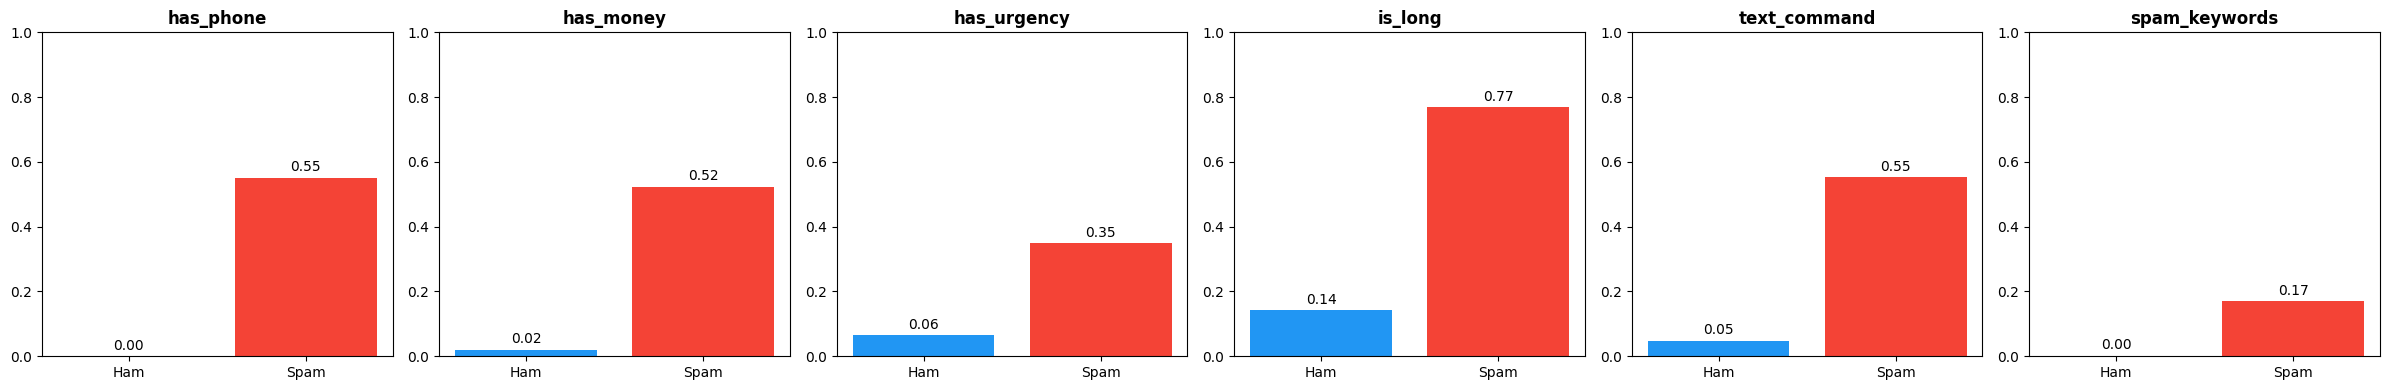

In [34]:
#creating one subplot per feature
fig, axes = plt.subplots(1, len(feature_cols), figsize=(4 * len(feature_cols), 4))

#making axes iterable for consistency per feature
if len(feature_cols) == 1:
    axes = [axes]

#loop through each feature to see how it differs between spam and ham
for i, feature in enumerate(feature_cols):

    #average/rate of the feature for each class
    ham_rate  = df[df['spam'] == 0][feature].mean()
    spam_rate = df[df['spam'] == 1][feature].mean()

    #side by side comparison
    axes[i].bar(['Ham', 'Spam'],
                [ham_rate, spam_rate],
                color=['#2196F3', '#F44336'])
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_ylim(0, 1)  #keeping plots on same scale for comparison

    #labels
    axes[i].text(0, ham_rate + 0.02, f'{ham_rate:.2f}', ha='center')
    axes[i].text(1, spam_rate + 0.02, f'{spam_rate:.2f}', ha='center')

#so plots don’t overlap
plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

The first feature I did was capturing messages containing "command words" because I feel that this is very common in spam texts I recieve. They frequently have some kind of "call to action" requesting the user replies, texts back, or claims they've won something.

The second feature I chose was similar to the first, but it captures messages containing what I called "suspicious" words. Words like: prize, guaranteed, selected, congratulations. These words are often indicative of spam messages because its rare natural "ham" messages are containing those.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

The feature with the largest gap is "is_long", which shows that the length of a message shows a strong difference in whether a message is "ham" or spam. A large gap matters because it means the feature separates the two classes well. This matters because when a decision tree selects its root node, it looks for the feature that best splits the data into more “pure” groups. This is very important for information gain, which measures how much uncertainty, aka entropy, is reduced after a split.
The large gap shown in the feature “is_long” creates a clearer separation between spam and ham, so it results in higher information gain.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

The example spam messages all contain keywords that would be caught with the features I selected. However a spam message that is too short, or perhaps doesn't contain a call to action or suspicious word may slip through. I have seen spam messages to pay a toll bill or ticket, or to check the tracking on a USPS package that are relatively short and do not use sus words or a call to action. I did not include a feature that detects links or websites, so that may slip through the detection.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [35]:
#set X and y
X = df[feature_cols].values
y = df['spam'].values

#split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#print sizes
print('split sizes:')
print(f'  train: {len(y_train):,}')
print(f'  test : {len(y_test):,}')
print()

#check spam rate
print('spam rate:')
print(f'  train: {y_train.mean():.1%}')
print(f'  test : {y_test.mean():.1%}')

split sizes:
  train: 4,179
  test : 1,393

spam rate:
  train: 13.4%
  test : 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

The purpose of stratify=y is to make sure that the training and test sets have the same distribution as the original dataset. In this dataset, about 13% of the data is classified as spam, so it is rather imbalanced. It's important that we maintain that distribution in the training and test sets to reflect the nature of spam data. If we skipped the stratification, the split might create a train or test set with too many/few spam instances. That would lead to a unreliable model because it may perform better or worse than it should.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

Cross validation allows us to train and evaluate the model on multiple different splits of the data. I think this would be prefered in situations where the dataset is imbalanced, small, or to provide a better evaluation of the model's performance because just using the single train/test split may not have the best representation of the dataset's distribution. For example in our dataset with 13% spam messages, a single split may not be the most accurate representation even with stratification. Using k-fold cross validation allows us to evaluate multiple splits of the dataset that maintain the distribution, so we can feel that the results of are more reliable.  

---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


number of leaves: 14



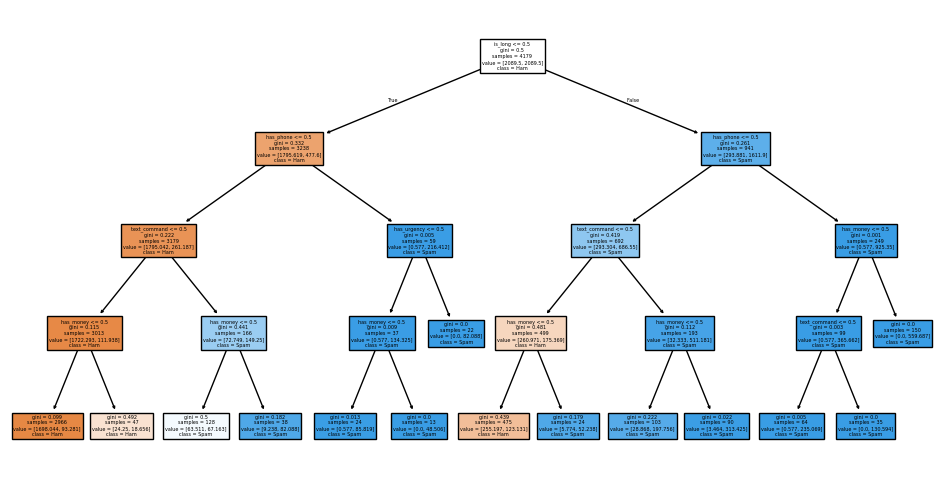

Decision tree rules:
|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- text_command <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 0
|   |   |--- text_command >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- text_command <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- text_command >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   

In [36]:
model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

#number of leaves
print('number of leaves:', model.get_n_leaves())
print()

#tree
plt.figure(figsize=(12, 6))
plot_tree(model,
          feature_names=feature_cols,
          class_names=['Ham', 'Spam'],
          filled=True)
plt.show()

#rules
print('Decision tree rules:')
print(export_text(model, feature_names=feature_cols))


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


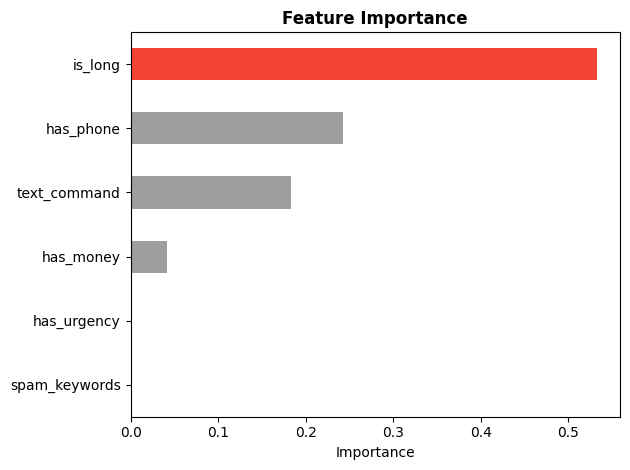

In [37]:
#getting feature importances
importances = model.feature_importances_

#creating series
imp = pd.Series(importances, index=feature_cols).sort_values()

#top feature
colors = ['#9E9E9E'] * len(imp)
colors[-1] = '#F44336'   #last one is largest after sorting

imp.plot(kind='barh', color=colors)

plt.title('Feature Importance', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


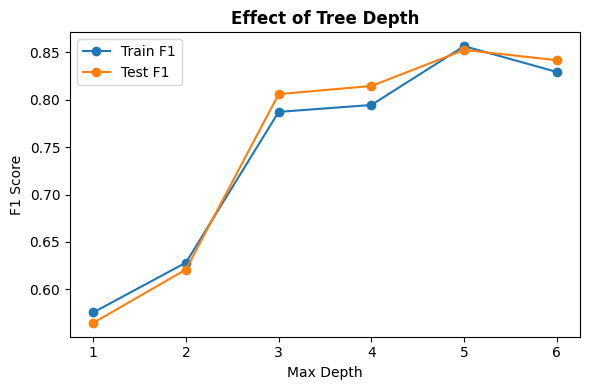

In [38]:
depths = [1, 2, 3, 4, 5, 6, None]

train_f1 = []
test_f1  = []

#loop over depths
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_f1.append(f1_score(y_train, y_train_pred))
    test_f1.append(f1_score(y_test, y_test_pred))

#results
plt.figure(figsize=(6, 4))
plt.plot(depths, train_f1, marker='o', label='Train F1')
plt.plot(depths, test_f1, marker='o', label='Test F1')

plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.title('Effect of Tree Depth', fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [39]:
#nb model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

BernoulliNB()

---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


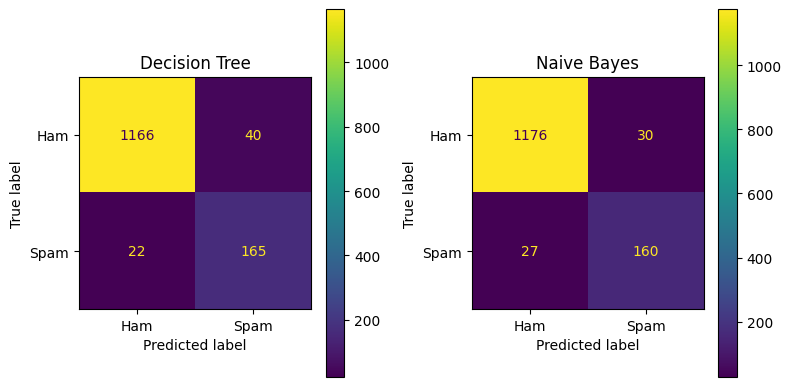

Decision Tree:
  TP: 165, FP: 40, FN: 22, TN: 1166

Naive Bayes:
  TP: 160, FP: 30, FN: 27, TN: 1176


In [40]:
#predictions
y_pred_dt = model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

#confusion matrices
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)

#plotting side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay(cm_dt, display_labels=['Ham', 'Spam']).plot(ax=axes[0])
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam']).plot(ax=axes[1])
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()


#showing TP, FP, FN, TN
print('Decision Tree:')
tn, fp, fn, tp = cm_dt.ravel()
print(f'  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}')

print()

print('Naive Bayes:')
tn, fp, fn, tp = cm_nb.ravel()
print(f'  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}')

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.955492   0.804878  0.882353  0.841837
1    Naive Bayes  0.959081   0.842105  0.855615  0.848806


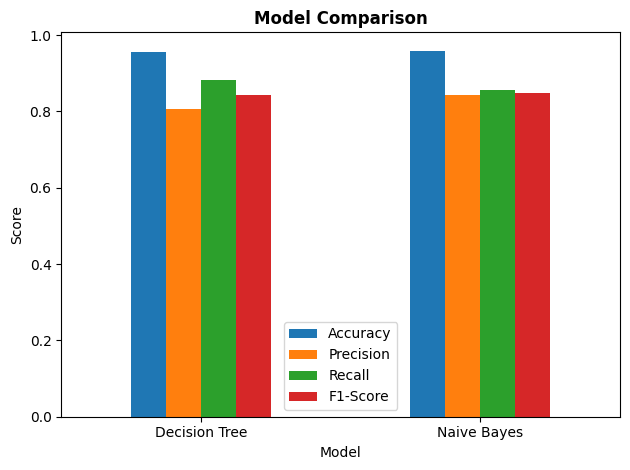

In [41]:
#metrics for decision tree
dt_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec  = recall_score(y_test, y_pred_dt)
dt_f1   = f1_score(y_test, y_pred_dt)

#metrics for naive bayes
nb_acc  = accuracy_score(y_test, y_pred_nb)
nb_prec = precision_score(y_test, y_pred_nb)
nb_rec  = recall_score(y_test, y_pred_nb)
nb_f1   = f1_score(y_test, y_pred_nb)

#creating the DataFrame
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes'],
    'Accuracy': [dt_acc, nb_acc],
    'Precision': [dt_prec, nb_prec],
    'Recall': [dt_rec, nb_rec],
    'F1-Score': [dt_f1, nb_f1]
})

print(metrics_df)

#grouped bar chart

plot_df = metrics_df.set_index('Model')
plot_df.plot(kind='bar')

plt.title('Model Comparison', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [42]:
#cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#decision tree
dt_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
#naive bayes
nb_scores = cross_val_score(nb_model, X, y, cv=cv, scoring='f1')

print('Cross Validation:')
print(f'  Decision Tree: {dt_scores.mean():.3f}')
print(f'  Naive Bayes : {nb_scores.mean():.3f}')

Cross Validation:
  Decision Tree: 0.809
  Naive Bayes : 0.852


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*

True Postives: 165
False Negatives: 22
False Positives: 40

*Naive Bayes:*

True Positives: 160
False Negatives: 27
False Positives: 30

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

In step one I suggested that recall would be the most important metric because it would evaluate the amount of spam detected out of all the spam present (true positives and false negatives). By that standard, the decision tree model performs better over the naive bayes. The recall is 88.2% to the naive bayes model's 85.6%; additionally, it catches more spam messages (165 vs. 160) and has fewer false negatives (22 vs. 27). However, the cross-validation results show that the naive bayes model has a higher average F1-score (0.852 vs. 0.809). I interpret that to mean the naive bayes model has a better balance of precision and recall overall. So, the decision tree is better at catching spam, but the naive bayes is more consistent across the different data splits.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

After evaluating the performance of two models' performance of spam message detection, I reccomend using a Naive Bayes model for consistent and reliable spam detection. This model achieved a higher cross validated F1-score of 0.852 compared to a score of 0.809 for the Decision Tree model. This metric is important to my decision becuase it indicates that the Naive Bayes model more consistently provides a better overall balance between catching spam and avoiding false alarms. While the Decision Tree catches slightly more spam messages, it also produced more false positives which might lead to legitimate messages being blocked. I'd still like to highlight that a weakness of the Naive Bayes model is that it misses slightly more spam messages (27 false negatives vs 22 for the Decision Tree), meaning the model could allow some spam through. To improve performance, I suggest we could engineer additional features such as detecting suspicious URLs or other message patterns to better capture evolving spam message characteristics.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

I think the feature I built using "suspicious" words may fail in detecting modern spam. Words such as guaranteed, prize, selected, congratulations, are commonly know to be spam these days, and users may be wary of interacting with those messages. In recent times, I have seen spam messages that imitate more natural or reasonable messages someone may recieve. For example, a message regarding delivery of a package, a toll bill, or a job offer. These are notices that users may interact with without assuming they are spam.
Additionally, I think the feature regarding message length may not be applicable to modern spam, despite it being the most prominent feature in this model. I think spam messages today can more closely mimic a "normal" message, so the length may vary. For example, I recently recieved a spam message that said : "You have a new unread snapchat message!" with a link attached. The message was very short, and did not contain any suspicious language. I think adapting feature engineering as spam messages continue to evolve and change would be the best way to dectect spam more effectively.  
